In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Movie shape: (86537, 3)
Rating shape: (33832162, 4)

 Movies head:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

 Rating head:
   userId  movieId  rating   timestamp
0       1        1     4.0  1225734739
1       1      110     4.0  1225865086
2       1      158     4.0  1225733503
3       1      260     4.5  1225735204
4       1      356     5.0  1225735119

 Missing values:
movieId    0
title      0
genres     0
dtype: int64
userId       0
movi

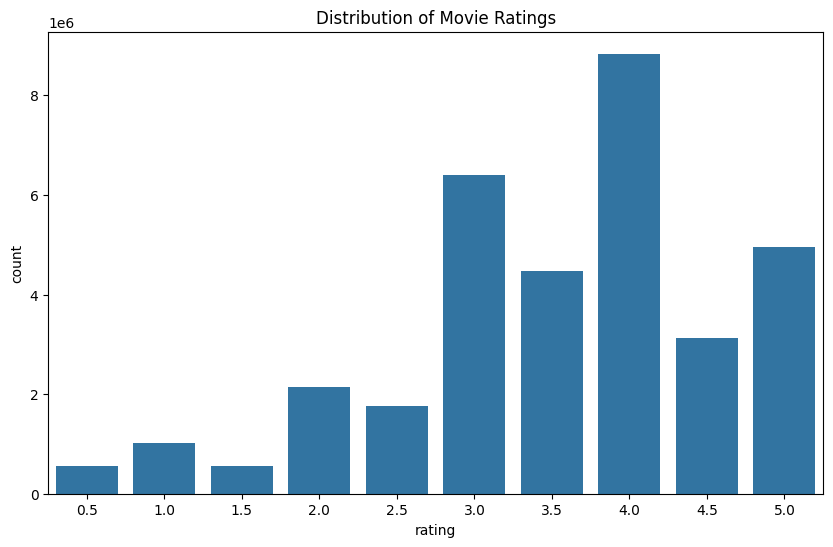


 Rating per user statistics:
count    330975.00000
mean        102.21969
std         232.15453
min           1.00000
25%          15.00000
50%          31.00000
75%          98.00000
max       33332.00000
Name: rating, dtype: float64

 Rating per movie statistics:
count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
Name: rating, dtype: float64


In [2]:
movie = pd.read_csv('../data/movies.csv')
rating = pd.read_csv('../data/ratings.csv')
links = pd.read_csv('../data/links.csv')
tags = pd.read_csv('../data/tags.csv')

print("Movie shape:", movie.shape)
print("Rating shape:", rating.shape)

print("\n Movies head:")
print(movie.head())

print("\n Rating head:")
print(rating.head())

print("\n Missing values:")
print(movie.isnull().sum())
print(rating.isnull().sum())

#Basic Statistics
print("Rating Statistics:")
print(rating["rating"].describe())

#Distribution of Ratings
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=rating)
plt.title('Distribution of Movie Ratings')
plt.savefig('../data/rating_distrubution.png')
plt.show()

#Number of rating per user
rating_per_user = rating.groupby('userId')['rating'].count()
print("\n Rating per user statistics:")
print(rating_per_user.describe())

#Number of ratings per movie
rating_per_user = rating.groupby('movieId')['rating'].count()
print("\n Rating per movie statistics:")
print(rating_per_user.describe())

In [4]:
#Additiona; analysis

movie_rating_counts= rating.groupby('movieId')['rating'].count()
top_10_rated = movie_rating_counts.sort_values(ascending=False).head(10)
print("\n Top 10 rated movies: ")
for movie_id, count in top_10_rated.items():
    movie_title = movie[movie['movieId']==movie_id]['title'].values[0]
    print(f"{movie_title}: {count} ratings")
    
#Avegarage rating per movie

avg_rating_per_movie = rating.groupby('movieId')['rating'].mean()
print(f"Average rating per movie statistics: {avg_rating_per_movie.mean():.2f}" )

#Data analysis 

if 'timestamp' in rating.columns:
    rating['date'] = pd.to_datetime(rating['timestamp'],unit='s')
    print(f"\n Rating over time: {rating['date'].min()} to {rating['date'].max()}")


 Top 10 rated movies: 
Shawshank Redemption, The (1994): 122296 ratings
Forrest Gump (1994): 113581 ratings
Pulp Fiction (1994): 108756 ratings
Matrix, The (1999): 107056 ratings
Silence of the Lambs, The (1991): 101802 ratings
Star Wars: Episode IV - A New Hope (1977): 97202 ratings
Fight Club (1999): 86207 ratings
Schindler's List (1993): 84232 ratings
Jurassic Park (1993): 83026 ratings
Star Wars: Episode V - The Empire Strikes Back (1980): 80200 ratings
Average rating per movie statistics: 3.01

 Rating over time: 1995-01-09 11:46:44 to 2023-07-20 08:53:33
